# Introduction
This web site is running a "Jupyter notebook," which allows you to execute interactive Octave
code directly in your browser. Each (part of a code) line preceeded by a percent symbol "%" is a code comment.

To execute any Octave commands, first enter the commands in a code cell, and then depress the "shift" and "enter" keys on your keyboard at the same time, making sure that your cursor is placed inside of the code cell.
I refer to this as "< shift \> < enter \>" in my instructions below.

The output from this notebook will be used to provide answers for this lesson's practice
quiz. As you proceed through the specialization, you will use more and more Jupyter notebooks
to write Octave code to implement Kalman-filter algorithms.

In [14]:
% Place your cursor in this input code cell. Then, type < shift >< enter > to execute

rms = @(x) sqrt(mean((x).^2)); % define root-mean-squared function

randn("state",0);
rand("state",0);
randg("state",0);

### Set up brute-force Bayesian inference solution
The next notebook cells implement the initialization functions.

In [15]:
% User-specified parameter values
nIter  =  201; % iterations 0..200
xMin   =   -3; % minimum value of xk that is considered
xMax   =    3; % maximum value of xk that is considered

sigmaW =  0.2; % process-noise standard deviation
sigmaV =  0.1; % sensor-noise standard deviation
nR     =  500; % number of regions into which xk is divided
nR     =  100; % number of regions into which xk is divided
alpha  = 0.99; % model state-equation parameter

In [16]:
% Create sequence of true states and observations from model
x = zeros(nIter+1,1); % storage for true states for k = [0..200]
z = zeros(nIter  ,1); % storage for measurements for k = [1..200]

x(1) = sigmaW*randn(1);
for kk=1:nIter
  x(kk+1) = alpha*x(kk) + sigmaW*randn(1);
  z(kk  ) = 0.1*x(kk)^3 + sigmaV*randn(1);
end
x = x(1:nIter); % truncate to [0..200]

In [17]:
% Initialize the estimator by reserving memory
xVals = linspace(xMin,xMax,nR)';  % these are the region edges
w     = mean(diff(xVals));        % this is the region width

fPlus   = zeros(nR,nIter); % f(x{k} | Z{k})
fMinus  = zeros(nR,1);     % f(x{k} | Z{k-1})
xHatMed = zeros(nIter,1);  % median of f(x{k} | Z{k})
xLowBnd = zeros(nIter,1);  % lower confidence of f(x{k} | Z{k})
xHiBnd  = zeros(nIter,1);  % upper confidence of f(x{k} | Z{k})

% Initialize f(x{0} | Z{0})
prior = normpdf(xVals,0,sigmaW); % f(x{0} | Z{-1})
fPlus(:,1) = normpdf(z(1),0.1*xVals.^3,sigmaV).*prior; % not normalized
fPlus(:,1) = fPlus(:,1)/trapz(xVals,fPlus(:,1)); % normalize f(x{0} | Z{0})

### Compute the brute-force Bayesian inference solution
The next notebook cells implement the trapezoidal integration (approximate) Bayesian inference solution.

In [18]:
% Loop to compute f(x{k} | Z{k})
for kk = 2:nIter % when kk = 2, k = 1 (avoid MATLAB index of 0)
  for theR = 1:nR % find f(x{k}=x{i}|x{k-1}) for each x{i}
    % compute prior = f(x{k} | x{k-1})
    prior  = normpdf(xVals(theR),alpha*xVals,sigmaW); 
    % calc fMinus(theR) = f(x{k} | Z{k-1}) for x{k} = xVals(theR)
    fMinus(theR) = trapz(xVals,prior.*fPlus(:,kk-1)); 
  end % have now computed fMinus = f(x{k} | Z{k-1})

  % find likelihood = f(z{k} | x{k}) and fPlus = f(x{k} | Z{k})
  likelihood = normpdf(z(kk),0.1*xVals.^3,sigmaV);
  fPlus(:,kk) = likelihood.*fMinus; % not yet normalized
  fPlus(:,kk) = fPlus(:,kk)/trapz(xVals,fPlus(:,kk)); % normalized

  % Find median, 95% confidence interval
  percentiles = cumtrapz(xVals,fPlus(:,kk));
  iMedian = find(percentiles <= 0.5,1,'last');
  iLower = find(percentiles <= 0.025,1,'last');
  if isempty(iLower), iLower = 1; end
  iUpper = find(percentiles >= 0.975,1,'first');
  if isempty(iUpper), iUpper = length(xVals); end
  xHatMed(kk) = xVals(iMedian); % store the median
  xLowBnd(kk) = xVals(iLower);  % store the lower conf. bound
  xHiBnd(kk)  = xVals(iUpper);  % store the upper conf. bound
  
  if mod(kk,10) == 0
    fprintf('Completed iteration %d out of %d\n',kk,nIter);
  end
end % end of main loop, "for kk = 2:nIter"

[~,iMax] = max(fPlus);      % Find index of the mode for each iter
xHatMode = xVals(iMax);     % Store the mode for each iteration
xHatMean = xVals'*fPlus.*w; % Compute the mean for each iteration

Completed iteration 10 out of 201
Completed iteration 20 out of 201
Completed iteration 30 out of 201
Completed iteration 40 out of 201
Completed iteration 50 out of 201
Completed iteration 60 out of 201
Completed iteration 70 out of 201
Completed iteration 80 out of 201
Completed iteration 90 out of 201
Completed iteration 100 out of 201
Completed iteration 110 out of 201
Completed iteration 120 out of 201
Completed iteration 130 out of 201
Completed iteration 140 out of 201
Completed iteration 150 out of 201
Completed iteration 160 out of 201
Completed iteration 170 out of 201
Completed iteration 180 out of 201
Completed iteration 190 out of 201
Completed iteration 200 out of 201


### Plot results

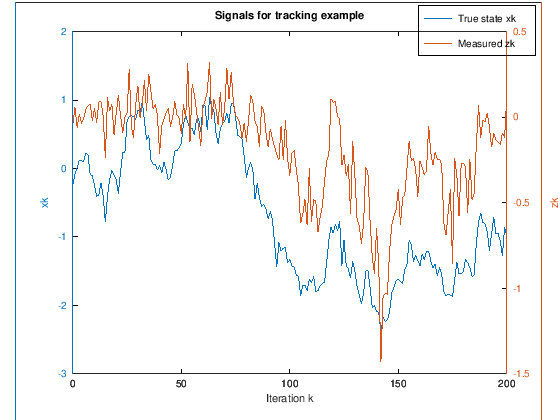

In [19]:
ax = plotyy(0:nIter-1,x,0:nIter-1,z);
ylabel(ax(1),'xk'); ylabel(ax(2),'zk');

legend('True state xk','Measured zk'); 

title('Signals for tracking example');
xlabel('Iteration k'); 

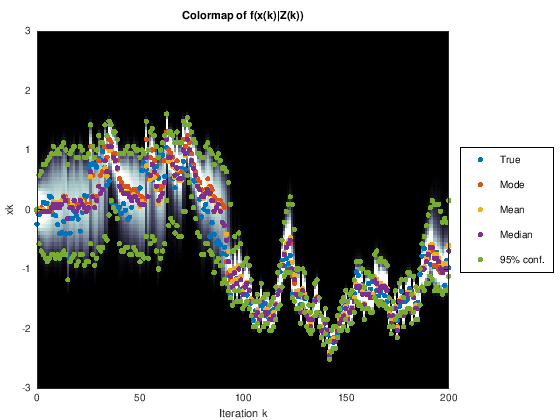

In [20]:
% Plot the colormap of the pdfs versus iteration
colormap('bone')
imagesc(0:nIter-1,xVals,fPlus); hold on 
caxis([0,prctile(fPlus(:),95)]); % more white on plot
hp = plot(0:nIter-1,x,'.',0:nIter-1,xHatMode,'.',...
          0:nIter-1,xHatMean,'.',0:nIter-1,xHatMed,'.',...
          [0:nIter-1,0:nIter-1],[xHiBnd; xLowBnd],'.'); 
set(hp,'markersize',12); set(gca,'ydir','normal'); % undo default strange Y direction

xlabel('Iteration k'); ylabel('xk');
xlim([0 nIter-1]); ylim([xMin xMax]);
title('Colormap of f(x(k)|Z(k))');
legend(hp,{'True','Mode','Mean','Median','95% conf.'},'location','eastoutside');

### Compute numeric result (you will need to generalize this code for the practice quiz)

In [21]:
fprintf('RMS error of mean estimate is %g\n',rms(x(:)-xHatMean(:)))

RMS error of mean estimate is 0.29464


In [24]:
fprintf('RMS error of mean estimate is %g\n',rms(x(:)-xHatMode(:)))

RMS error of mean estimate is 0.31399


In [23]:
fprintf('RMS error of mean estimate is %g\n',rms(x(:)-xHatMed(:)))

RMS error of mean estimate is 0.291063
